# 1D Derivatives

In this notebook, you will work with derivatives. You will derive analytical derivatives of functions (you may use the derivatives table from the first task) and approximate them with finite differences.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import json_tricks

answer = {}

# Task 1. 1st order derivatives

Below are 8 functions. For these functions, write the derivatives using NumPy.

For example, if the function is $$f(x) = x^2$$, its derivative is $$\frac{\partial f}{\partial x} = 2x$$

Then the code should be:
- for the function (given in the cell below):
  ```python
  def f(x):
    return x ** 2
  ```
- for the derivative (should be implemented):
  ```python
  def df(x):
    return 2 * x
  ```

In [16]:
xs = np.linspace(-10, 10, 100)

def f1(x):
    return 3 * x ** 2 + 5 * x - 7

def f2(x):
    return np.sin(x) + np.cos(x)

def f3(x):
    return x ** 2 * np.exp(x)

def f4(x):
    return (x ** 2 + 1) / (x + 2)

def f5(x):
    return np.log(3 * x ** 2 + 5)

def f6(x):
    return x ** 2 * np.exp(x) / np.log(x)

In [17]:
def df1(x):
    res = x * 6 + 5
    ## YOUR CODE HERE
    return res

def df2(x):
    res = -np.sin(x) + np.cos(x)
    ## YOUR CODE HERE
    return res

def df3(x):
    res =  x * 2 * np.exp(x) +  x** 2 * np.exp(x)
    ## YOUR CODE HERE
    return res

def df4(x):
    res = (2*x*(x+2)-(x**2+1)) / (x+2)**2
    ## YOUR CODE HERE
    return res

def df5(x):
    res = 6*x/(3*x**2+5)
    ## YOUR CODE HERE
    return res

def df6(x):
    res = x * 0
    ## YOUR CODE HERE
    u = x ** 2 * np.exp(x)
    v = np.log(x)
    u1 = (2*x*np.exp(x)) + (x**2*np.exp(x))
    v1 = np.log(x)
    res = (u1*v - v1*u)/v**2
    return res

# Task 2. 2nd order derivatives

For the same functions, write the second-order derivatives using NumPy.

In [ ]:
# мне говорили, что для физики точности в проценты достаточно, ниже лучше)
def ddf1(x):
    eps = 1e-5
    res = (df1(x*(1+eps)) - df1(x)) / eps
    res = 6
    return res

def ddf2(x):
    eps = 1e-5
    res = (df2(x*(1+eps)) - df2(x)) / eps
    return res

def ddf3(x):    
    eps = 1e-5
    res = (df3(x*(1+eps)) - df3(x)) / eps
    return res

def ddf4(x):
    eps = 1e-5
    res = (df4(x*(1+eps)) - df4(x)) / eps
    return res

def ddf5(x):
    eps = 1e-5
    res = (df5(x*(1+eps)) - df5(x)) / eps
    return res

def ddf6(x):
    eps = 1e-5
    res = (df6(x*(1+eps)) - df6(x)) / eps
    return res

In [19]:
fs = [f1, f2, f3, f4, f5, f6]
dfs = [df1, df2, df3, df4, df5, df6]
ddfs = [ddf1, ddf2, ddf3, ddf4, ddf5, ddf6]

# Task 3. Finite differences

Write a function that calculates finite differences:

$$\frac{df}{dx}(x_i) \approx \frac{f(x_{i + 1}) - f(x_{i})}{x_{i + 1} - x_i}$$

The inputs to this function are:
- values of the function $f(x_i)$ as `numpy.array` of shape $N$
- arguments $x_i$ as `numpy.array` of shape $N$

The output should be a `numpy.array` with approximate derivatives of shape $N - 1$.

In [21]:
def finite_differences(f, x):
    df_x = (f[1:] - f[:-1]) / (x[1:] - x[:-1])
    return df_x

# Comparison of finite differences with analytical derivatives

You can play with the code below to observe how the granularity of the arguments affects the precision of the approximation.

- the first row is the function itself
- the second row is the first derivative
- the third row is the second derivative

/tmp/ipykernel_4017/2559256138.py:30: RuntimeWarning: invalid value encountered in log
  v = np.log(x)
/tmp/ipykernel_4017/2559256138.py:32: RuntimeWarning: invalid value encountered in log
  v1 = np.log(x)
/tmp/ipykernel_4017/4073071017.py:19: RuntimeWarning: invalid value encountered in log
  return x ** 2 * np.exp(x) / np.log(x)


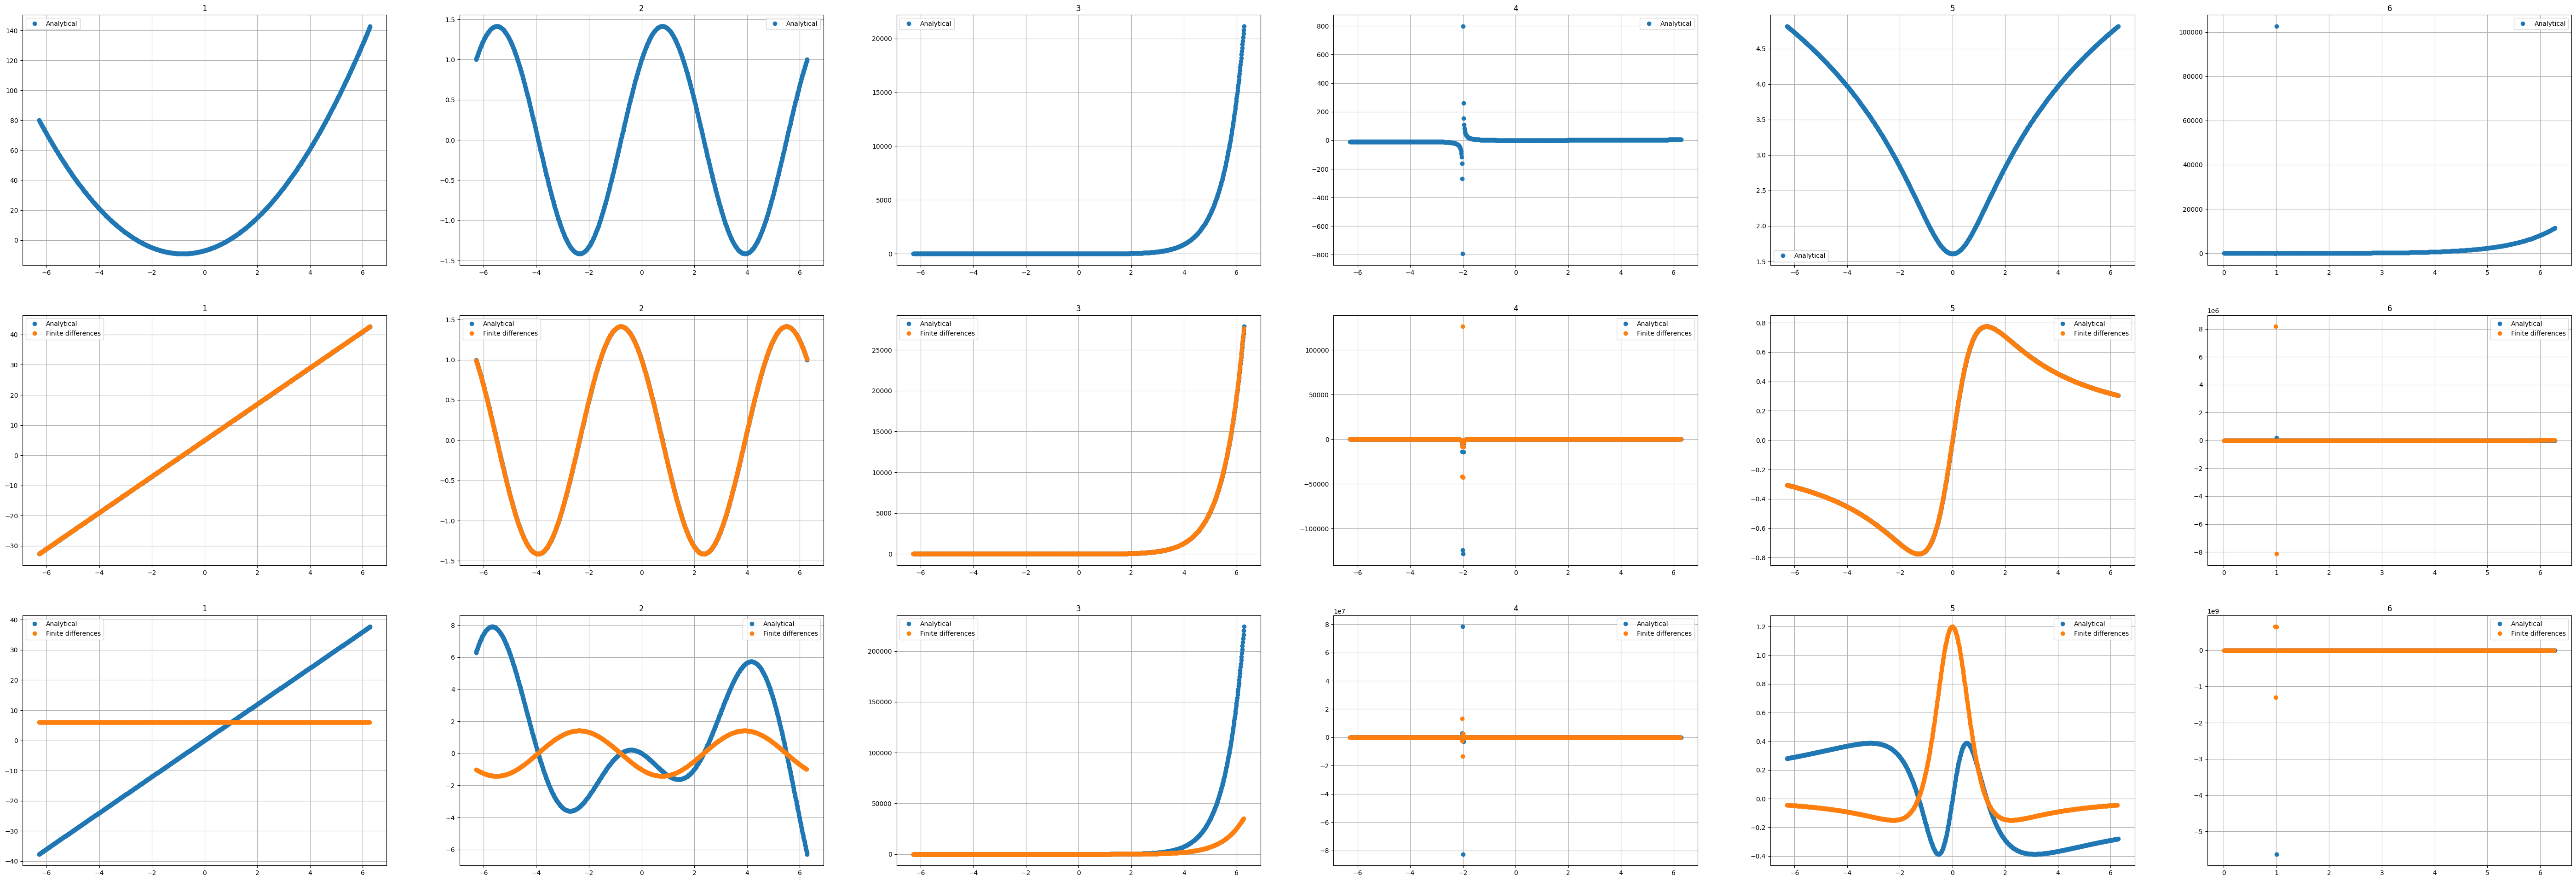

In [22]:
xs = np.linspace(
    -2*np.pi, 
    2*np.pi, 
    1000 # you can change this value. Check 100, 200, 500, 1000
)

answer['1D'] = {}

plt.figure(figsize=(96, 24))
index = 0
for f, df, ddf in zip(fs, dfs, ddfs):
    index += 1
    df_x = df(xs)
    ddf_x = ddf(xs)

    df_x_approx = finite_differences(f(xs), xs)
    ddf_x_approx = finite_differences(df_x_approx, xs[:-1])
    
    answer['1D']['d' + str(index)] = df_x[~np.isnan(df_x)]
    answer['1D']['dd' + str(index)] = ddf_x[~np.isnan(ddf_x)]

    answer['1D']['d' + str(index) + '_approx'] = df_x_approx[~np.isnan(df_x_approx)]
    answer['1D']['dd' + str(index) + '_approx'] = ddf_x_approx[~np.isnan(ddf_x_approx)]
    

    plt.subplot(3, 8, index)
    plt.plot(xs, f(xs), 'o')
    plt.legend(['Analytical'])
    plt.grid()
    plt.title(str(index))

    plt.subplot(3, 8, 8 + index)
    plt.plot(xs, df_x, 'o')
    plt.plot(xs[:-1], df_x_approx, 'o')
    plt.legend(['Analytical', 'Finite differences'])
    plt.grid()
    plt.title(str(index))


    plt.subplot(3, 8, 16 + index)
    plt.plot(xs, ddf_x, 'o')
    plt.plot(xs[:-2], ddf_x_approx, 'o')
    plt.legend(['Analytical', 'Finite differences'])
    plt.grid()
    plt.title(str(index))


# 2D Derivatives and Gradients

Below are 2D functions. Find their derivatives with respect to $x$ and $y$, and return them as a pair of NumPy maps.

Note that in 2D, the `x` and `y` coordinates are 2D maps. Every number in these maps is the value of the $x$ or $y$ coordinate at that point.

`f` is also a map of values of the function $f$ for the corresponding coordinates $x$ and $y$.

Example:

```
x = np.array([
    [1, 2],
    [1, 2]
])

y = np.array([
    [1, 1],
    [2, 2]
])

f = x ** 2 + y ** 2
``` 

In [23]:
def f1(x, y):
    res = np.exp(-0.1 * (x**2 + y**2))
    return res

def f2(x, y):
    res = np.sin(x) * np.cos(y)
    return res

def f3(x, y):
    res = np.sin(x) + np.cos(y)
    return res

def f4(x, y):
    res = -np.exp(-0.2 * (x**2 + y**2)) + 0.5 * np.sin(3*x) * np.sin(3*y)
    return res

def f5(x, y):
    res = np.sin(x * 2) * np.cos(y * 2) + 0.2 * np.sin(5*x) * np.cos(5*y)
    return res

def f6(x, y):
    res = np.sin(5*x) * np.sin(5*y)
    return res

# Task 4. Find gradients of 2D functions

Write functions that calculate the gradients of the functions above. Each function should return a tuple of maps: $\frac{\partial f}{\partial x}$, $\frac{\partial f}{\partial y}$

In [24]:
def grad_f1(x, y):
    res = (np.exp(-0.1 * (x**2 + y**2)) * -0.1 * 2 * x, np.exp(-0.1 * (x**2 + y**2)) * -0.1 * 2 * y)
    return res

def grad_f2(x, y):
    res = (np.cos(x) * np.cos(y), -np.sin(x) * np.sin(y))
    return res

def grad_f3(x, y):
    res = (np.cos(x), -np.sin(y))
    return res

def grad_f4(x, y):
    res = (-np.exp(-0.2 * (x**2 + y**2))*(-0.2)*2*x + 0.5 * np.cos(3*x) *3*np.sin(3*y), 
           -np.exp(-0.2 * (x**2 + y**2))*(-0.2)*2*y + 0.5 * np.sin(3*x) * np.cos(3*y)*3)

    return res

def grad_f5(x, y):
    res = (np.cos(x * 2) * 2 * np.cos(y * 2) + 0.2 * np.cos(5*x) * 5 * np.cos(5*y),
           np.sin(x * 2) * np.sin(y * 2) * (-2) + 0.2 * np.sin(5*x) * np.sin(5*y) * (-5))
    return res

def grad_f6(x, y):
    res = (np.cos(5*x) * 5 * np.sin(5*y),
           np.sin(5*x) * np.cos(5*y) * 5)
    return res

# Task 5. 2D finite differences

For the map $f$ and for two maps of $x$ and $y$, write a function that calculates an approximate derivative by $x$ and $y$ using finite differences:

$\frac{\partial f}{\partial x} \approx \frac{f_{k + 1,l} - f_{k, l}}{x_{k+1, l} - x_{k, l}}$

$\frac{\partial f}{\partial y} \approx \frac{f_{k,l + 1} - f_{k, l}}{y_{k, l + 1} - y_{k, l}}$

In [25]:
def finite_differences_2d(f, x, y):
    df_y = (f[1:, :] - f[:-1, :]) / (y[1:, :] - y[:-1, :])
    df_x = (f[:, 1:] - f[:, :-1]) / (x[:, 1:] - x[:, :-1])
    return df_x, df_y

# Visualization

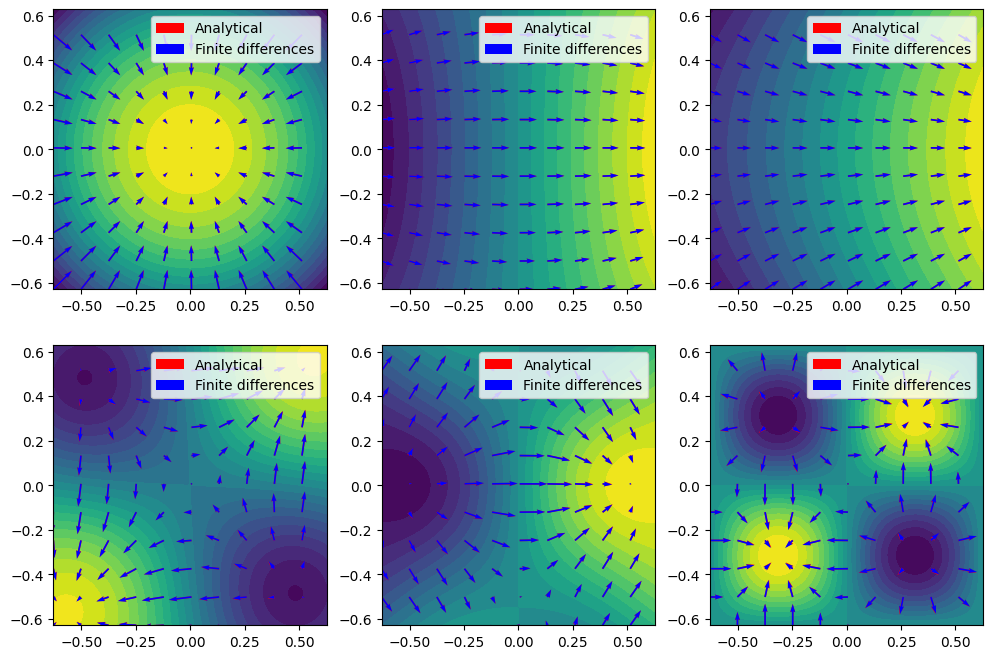

In [26]:
N = 100 # you can change this value. Check 10, 20, 50, 100

xs = np.linspace(-np.pi/5, np.pi/5, N)
ys = np.linspace(-np.pi/5, np.pi/5, N)

XS, YS = np.meshgrid(xs, ys)

fs = [f1, f2, f3, f4, f5, f6]
grad_fs = [grad_f1, grad_f2, grad_f3, grad_f4, grad_f5, grad_f6]

answer['2D'] = {}

plt.figure(figsize=(12, 8))
index = 0
for f, grad_f in zip(fs, grad_fs):
    # print(f)
    index += 1
    fs = f(XS, YS)
    df_x, df_y = grad_f(XS, YS)
    df_x_approx, df_y_approx = finite_differences_2d(fs, XS, YS)
    answer['2D']['grad_' + str(index)] = (df_x[~np.isnan(df_x)], df_y[~np.isnan(df_y)])
    answer['2D']['grad_' + str(index) + '_approx'] = (df_x_approx[~np.isnan(df_x_approx)], df_y_approx[~np.isnan(df_y_approx)])
    

    plt.subplot(2, 3, index)
    plt.contourf(xs, ys, fs, levels=20)
    plt.quiver(
        XS[:-1:10, :-1:10].flatten(),
        YS[:-1:10, :-1:10].flatten(),
        df_x[:-1:10, :-1:10].flatten(),
        df_y[:-1:10, :-1:10].flatten(),
        color='r',
    )
    plt.quiver(
        XS[:-1:10, :-1:10].flatten(),
        YS[:-1:10, :-1:10].flatten(),
        df_x_approx[::10, :-1:10].flatten(), 
        df_y_approx[:-1:10, ::10].flatten(),
        color='b'
    )
    plt.legend(['Analytical', 'Finite differences'])

Observe the plots above.
- What do they look like? Do they make sense?
- Do the gradients point in the fastest ascent direction?
- Are gradients orthogonal to the levels?



In [27]:
json_tricks.dump(answer, '.answer.json')

'{"1D": {"d1": {"__ndarray__": [-32.69911184307752, -32.62363814569398, -32.548164448310445, -32.4726907509269, -32.397217053543365, -32.32174335615983, -32.246269658776285, -32.17079596139274, -32.095322264009205, -32.01984856662567, -31.944374869242132, -31.868901171858596, -31.793427474475052, -31.717953777091516, -31.64248007970798, -31.567006382324436, -31.4915326849409, -31.416058987557363, -31.340585290173827, -31.26511159279029, -31.189637895406747, -31.114164198023204, -31.038690500639667, -30.96321680325613, -30.887743105872588, -30.81226940848905, -30.736795711105515, -30.66132201372198, -30.585848316338442, -30.5103746189549, -30.434900921571362, -30.359427224187826, -30.283953526804282, -30.20847982942074, -30.133006132037202, -30.057532434653666, -29.98205873727013, -29.906585039886593, -29.83111134250305, -29.755637645119513, -29.680163947735977, -29.604690250352434, -29.529216552968897, -29.45374285558536, -29.378269158201817, -29.302795460818288, -29.227321763434745, -